# Seguimiento mediante flujo óptico Lucas-Kanade

Este notebook aplica el método de Lucas-Kanade visto en la práctica de estimación de movimiento.

La idea básica es detectar puntos característicos en la imagen y seguir su desplazamiento entre frames consecutivos. En el proyecto se amplía esta técnica para procesar vídeos completos, guardar las trayectorias de los puntos y calcular métricas de desplazamiento.

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

# Ruta principal del proyecto
project_dir = Path(r"C:\Users\34689\Desktop\Glole\U\masterus\percep")

# Vídeo de entrada
video_path = project_dir / "data" / "synthetic_videos" / "synthetic_circle.mp4"

# Salidas
output_video_path = project_dir / "outputs" / "processed_videos" / "lucas_kanade_synthetic.mp4"
output_csv_path = project_dir / "outputs" / "plots" / "lucas_kanade_points.csv"

output_video_path.parent.mkdir(parents=True, exist_ok=True)
output_csv_path.parent.mkdir(parents=True, exist_ok=True)

print("Project directory:", project_dir)
print("Video path:", video_path)
print("Video exists:", video_path.exists())

Project directory: C:\Users\34689\Desktop\Glole\U\masterus\percep
Video path: C:\Users\34689\Desktop\Glole\U\masterus\percep\data\synthetic_videos\synthetic_circle.mp4
Video exists: True


In [10]:
cap = cv2.VideoCapture(str(video_path))

print("OpenCV can open video:", cap.isOpened())

if cap.isOpened():
    print("FPS:", cap.get(cv2.CAP_PROP_FPS))
    print("Frames:", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
    print("Width:", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
    print("Height:", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

OpenCV can open video: True
FPS: 30.0
Frames: 180
Width: 640
Height: 360


In [11]:
def track_motion_with_lucas_kanade(
    input_video_path: Path,
    output_video_path: Path,
):
    """
    Track visual feature points using Lucas-Kanade optical flow.
    """

    cap = cv2.VideoCapture(str(input_video_path))

    if not cap.isOpened():
        raise RuntimeError("Could not open the input video")

    fps = cap.get(cv2.CAP_PROP_FPS)
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(str(output_video_path), fourcc, fps, (width, height))

    ret, old_frame = cap.read()

    if not ret:
        raise RuntimeError("Could not read the first frame")

    old_gray = cv2.cvtColor(old_frame, cv2.COLOR_BGR2GRAY)

    # Parameters for feature detection
    feature_params = dict(
        maxCorners=80,
        qualityLevel=0.01,
        minDistance=5,
        blockSize=7
    )

    # Parameters for Lucas-Kanade optical flow
    lk_params = dict(
        winSize=(21, 21),
        maxLevel=3,
        criteria=(
            cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
            20,
            0.03
        )
    )

    # Detect initial feature points
    p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)

    if p0 is None:
        raise RuntimeError("No feature points found in the first frame")

    # Mask used to draw accumulated trajectories
    mask = np.zeros_like(old_frame)

    tracked_data = []
    frame_index = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        frame_gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

        # Calculate optical flow
        p1, status, error = cv2.calcOpticalFlowPyrLK(
            old_gray,
            frame_gray,
            p0,
            None,
            **lk_params
        )

        if p1 is None or status is None:
            # Re-detect points if tracking is lost
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
            if p0 is None:
                break
            continue

        good_new = p1[status == 1]
        good_old = p0[status == 1]

        displacements = []

        for new_point, old_point in zip(good_new, good_old):
            x_new, y_new = new_point.ravel()
            x_old, y_old = old_point.ravel()

            dx = x_new - x_old
            dy = y_new - y_old
            displacement = np.sqrt(dx**2 + dy**2)

            displacements.append(displacement)

            tracked_data.append({
                "frame": frame_index,
                "x_old": x_old,
                "y_old": y_old,
                "x_new": x_new,
                "y_new": y_new,
                "dx": dx,
                "dy": dy,
                "displacement": displacement
            })

            x_new_i, y_new_i = int(x_new), int(y_new)
            x_old_i, y_old_i = int(x_old), int(y_old)

            # Draw movement line
            mask = cv2.line(
                mask,
                (x_new_i, y_new_i),
                (x_old_i, y_old_i),
                (255, 0, 0),
                2
            )

            # Draw current point
            frame = cv2.circle(
                frame,
                (x_new_i, y_new_i),
                4,
                (0, 0, 255),
                -1
            )

        output_frame = cv2.add(frame, mask)

        mean_displacement = np.mean(displacements) if len(displacements) > 0 else 0

        cv2.putText(
            output_frame,
            f"Frame: {frame_index} | LK points: {len(good_new)}",
            (20, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        cv2.putText(
            output_frame,
            f"Mean displacement: {mean_displacement:.2f} px/frame",
            (20, 60),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        writer.write(output_frame)

        # Update previous frame and points
        old_gray = frame_gray.copy()

        if len(good_new) < 5:
            p0 = cv2.goodFeaturesToTrack(old_gray, mask=None, **feature_params)
            if p0 is None:
                break
        else:
            p0 = good_new.reshape(-1, 1, 2)

        frame_index += 1

    cap.release()
    writer.release()

    tracked_df = pd.DataFrame(tracked_data)

    return tracked_df

In [12]:
tracked_df = track_motion_with_lucas_kanade(
    input_video_path=video_path,
    output_video_path=output_video_path
)

tracked_df.to_csv(output_csv_path, index=False)

print("Lucas-Kanade video saved at:", output_video_path)
print("Tracked points saved at:", output_csv_path)
print("Number of tracked point records:", len(tracked_df))

tracked_df.head()

Lucas-Kanade video saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\processed_videos\lucas_kanade_synthetic.mp4
Tracked points saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\lucas_kanade_points.csv
Number of tracked point records: 2864


,frame,x_old,y_old,x_new,y_new,dx,dy,displacement
0,0,53.0,157.0,55.018902,160.998123,2.018902,3.998123,4.478946
1,0,36.0,173.0,37.997101,176.986877,1.997101,3.986877,4.459104
2,0,83.0,173.0,84.999756,176.999054,1.999756,3.999054,4.471180
3,0,53.0,203.0,55.000961,207.000061,2.000961,4.000061,4.472620
4,0,67.0,156.0,69.000984,160.000687,2.000984,4.000687,4.473190


In [13]:
lk_summary = tracked_df.groupby("frame").agg(
    mean_x=("x_new", "mean"),
    mean_y=("y_new", "mean"),
    mean_dx=("dx", "mean"),
    mean_dy=("dy", "mean"),
    mean_displacement=("displacement", "mean"),
    num_points=("displacement", "count")
).reset_index()

summary_csv_path = project_dir / "outputs" / "plots" / "lucas_kanade_summary.csv"
lk_summary.to_csv(summary_csv_path, index=False)

print("Lucas-Kanade summary saved at:", summary_csv_path)
lk_summary.head()

Lucas-Kanade summary saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\lucas_kanade_summary.csv


,frame,mean_x,mean_y,mean_dx,mean_dy,mean_displacement,num_points
0,0,61.687592,183.748764,2.000090,3.998771,4.471083,16
1,1,64.685577,188.748688,2.997989,4.999915,5.829849,16
2,2,67.685249,193.748611,2.999667,4.999931,5.830722,16
3,3,70.685425,197.748718,3.000181,4.000103,5.000192,16
4,4,73.684746,202.748917,2.999318,5.000195,5.830768,16


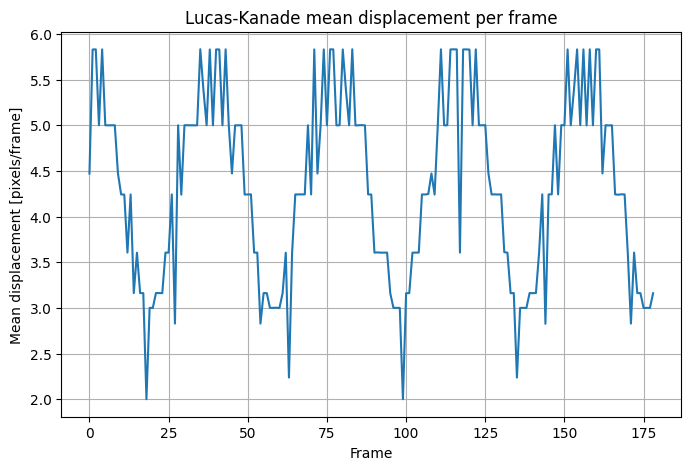

Displacement plot saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\lucas_kanade_mean_displacement.png


In [14]:
displacement_plot_path = project_dir / "outputs" / "plots" / "lucas_kanade_mean_displacement.png"

plt.figure(figsize=(8, 5))
plt.plot(lk_summary["frame"], lk_summary["mean_displacement"])
plt.xlabel("Frame")
plt.ylabel("Mean displacement [pixels/frame]")
plt.title("Lucas-Kanade mean displacement per frame")
plt.grid(True)
plt.savefig(displacement_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Displacement plot saved at:", displacement_plot_path)

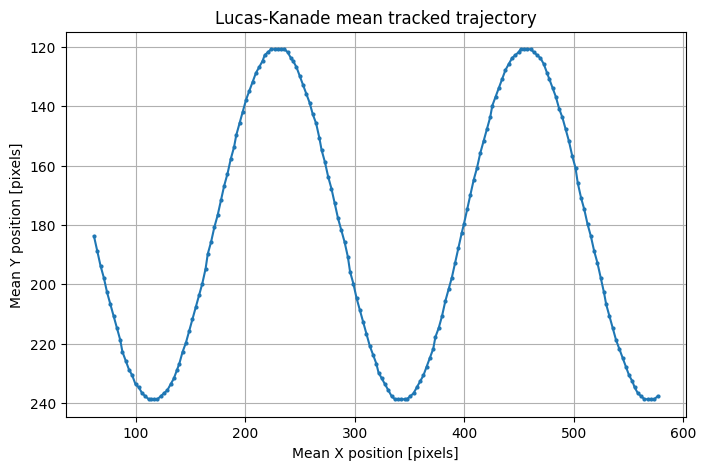

Trajectory plot saved at: C:\Users\34689\Desktop\Glole\U\masterus\percep\outputs\plots\lucas_kanade_mean_trajectory.png


In [15]:
lk_trajectory_plot_path = project_dir / "outputs" / "plots" / "lucas_kanade_mean_trajectory.png"

plt.figure(figsize=(8, 5))
plt.plot(lk_summary["mean_x"], lk_summary["mean_y"], marker="o", markersize=2)
plt.gca().invert_yaxis()
plt.xlabel("Mean X position [pixels]")
plt.ylabel("Mean Y position [pixels]")
plt.title("Lucas-Kanade mean tracked trajectory")
plt.grid(True)
plt.savefig(lk_trajectory_plot_path, dpi=150, bbox_inches="tight")
plt.show()

print("Trajectory plot saved at:", lk_trajectory_plot_path)